## EN


In the twilight of the basement, illuminated only by the dim glow of a MacBook Air screen, the potion-maker Vadim conjured over his cauldron. He decided to brew the absolute elixir of knowledge — the SOTA-Neo potion.

Vadim tossed a couple of pinches of CatBoost extract into the cauldron for brewing speed, poured in the tears of the Optuna optimizer, and prepared to drink. But then his hand trembled. Instead of a pinch of regularization, he accidentally dumped a whole jar of toxic torch.zeros() powder into the concoction, and dropped the root of chaos on top, which the local witch called transformer's module shuffle.

The cauldron flared up with a green flame. Without thinking twice, Vadim scooped up a mug and downed it in one gulp.

In the corner of the room stood his two faithful familiars — transformer golems. The potion's fumes engulfed them completely.

The first golem inhaled the smoke, and short-circuited. The random weights in his neuron matrices were brutally zeroed out, simply vanishing into oblivion. The dude slumped to the floor, having lost half of his knowledge. He drooled and muttered scraps of tokens:
— Mom... washed the... [MASK]... the gradient... vanished... help, my forward pass is empty, I can't feel my embeddings... I am just a sparse matrix of pain...

But the second golem got it even worse. The potion hit him right in the architecture. Slightly fewer random weights were zeroed out, but in return, his transformer blocks were shuffled into a pure chaotic mess. The 21st layer took the place of the 2nd, the 5th flew to the very end. His multi-head attention was turned inside out. The golem jumped up, his eyes burned with a mad light, and he began generating absolute schizo-nonsense with supreme confidence:

— The glokaya kuzdra shteko budlanula the softmax, because the self-attention cucumber calculated the dot product of semolina porridge! If you shave a hedgehog through backpropagation, the Renaissance epoch will collapse into a third-rank tensor! Glory to the great hyperparameter, for fried nails are the best dataset for predicting the weather on Jupiter! Attention is all you need, but the macaroni is already cold, bro, run backward on the dumplings!

## RU

В полумраке подвала, освещенного лишь тусклым свечением экрана MacBook Air, зельевар Вадим колдовал над котлом. Он решил сварить абсолютный эликсир познания — зелье SOTA-Neo.

Вадим закинул в котел пару щепоток экстракта CatBoost для скорости варки, залил всё слезами оптимизатора Optuna и приготовился пить. Но тут рука дрогнула. Вместо щепотки регуляризации он случайно вывалил в варево целую банку ядовитого порошка torch.zeros(), а сверху уронил корень хаоса, который местная ведьма называла transformer`s module shuffle.

Котел вспыхнул зеленым пламенем. Вадим, недолго думая, зачерпнул кружку и залпом выпил.

В углу комнаты стояли два его верных фамильяра — голема-трансформера. Пары зелья накрыли их с головой.

Первый голем вдохнул дым, и его закоротило. У него жестко занулились случайные веса в матрицах нейронов просто отлетели в небытие. Чувак осел на пол, потеряв половину своих знаний. Он пускал слюни и бормотал обрывки токенов:
— Мама... мыла... [MASK]... градиент... затух... помогите, мой forward пуст, я не чувствую своих эмбеддингов... я просто разреженная матрица боли...

Но второму голему досталось еще жестче. Зелье ударило ему прямо в архитектуру. Случайных весов занулилось чуть поменьше, но зато его трансформерные блоки перемешались в лютую кашу. 21-й слой встал на место 2-го, 5-й улетел в самый конец. Его многоголовое внимание вывернуло наизнанку. Голем вскочил, глаза загорелись безумным светом, и он начал генерировать абсолютный шизо-бред на уверенных щах:

Глокая куздра штеко будланула софтмакс, потому что огурец самовнимания вычислил скалярное произведение манной каши! Если побрить ежа через бэкпропагейшн, то эпоха ренессанса схлопнется в тензор третьего ранга! Слава великому гиперпараметру, ведь жареные гвозди — это лучший датасет для предсказания погоды на Юпитере! Внимание — это всё, что тебе нужно, но макароны уже остыли, братишка, запускай backward на пельмени!

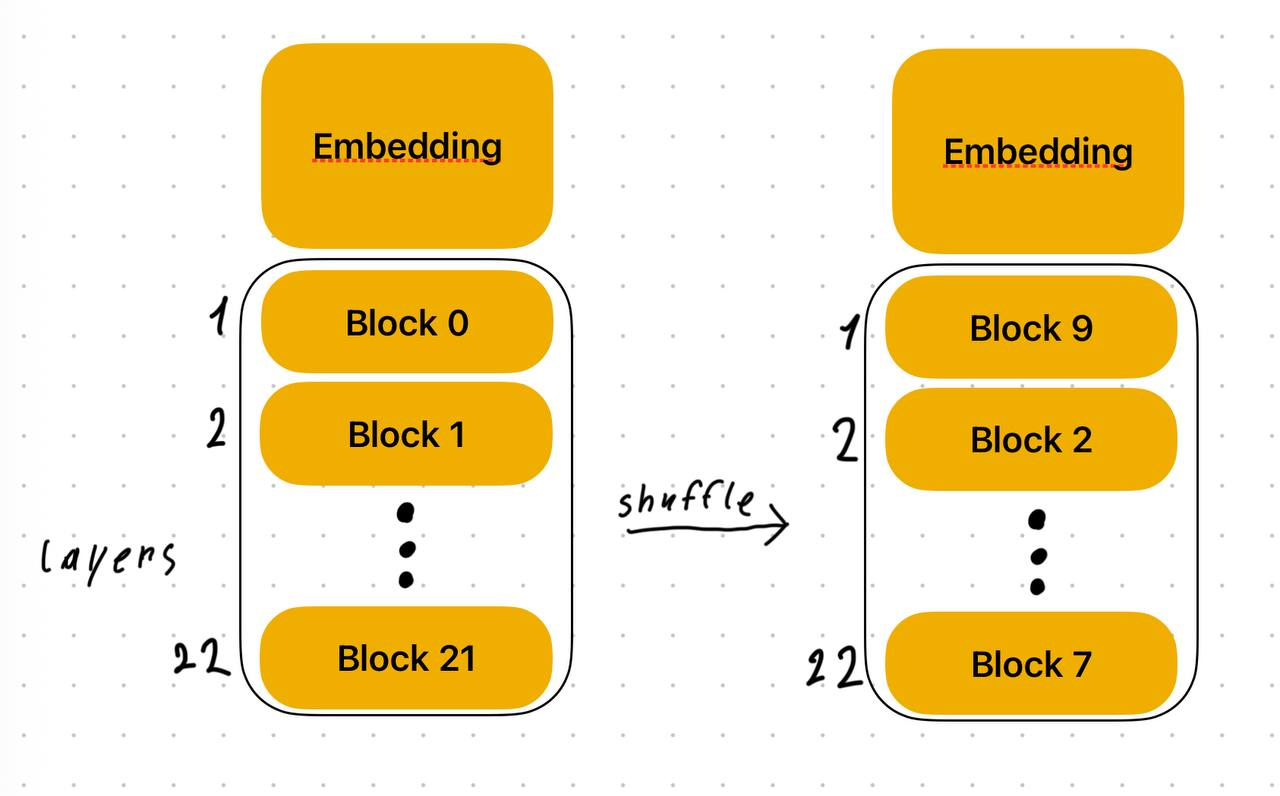

# !!!!! attention please
## Overview
In short, you have two transformers — these are two similar checkpoints of the same model, which was trained on a similar subset of data (the `test` and `train` sets are not included in it).

## Data
*   `/kaggle/input/competitions/neoai-2026-day-1-nlp/coca_cola_zero` — some weights are randomly zeroed out, but the transformer blocks are in the correct order.
*   `/kaggle/input/competitions/neoai-2026-day-1-nlp/coca_cola_shuffle` — a smaller portion of random weights are zeroed out, making it a higher quality checkpoint, but this model's transformer blocks are shuffled (as seen in the illustration above).
*   Users in the `train` and `test` sets do not overlap. This is a re-identification task.

## Evaluation
Predictions will be evaluated using the **mAP@5** metric. 

For each message in the test set, you need to find the 5 most relevant messages, where a recommended message is considered relevant if it was written by the same user.

# !!!!!! ВНИМАНИЕ
## Overview
Короче говоря, у вас есть два трансформера — это два похожих чекпоинта одной модели, которая была обучена на схожем сабсете данных (`test` и `train` в него не входят).

## Data
*   `/kaggle/input/competitions/neoai-2026-day-1-nlp/coca_cola_zero` — часть весов занулена случайным образом, трансформер-блоки находятся в правильном порядке.
*   `/kaggle/input/competitions/neoai-2026-day-1-nlp/coca_cola_shuffle` — часть случайных весов занулена в меньшем масштабе, это более качественный чекпоинт, но у этой модели перемешаны трансформер-блоки (как на иллюстрации выше).
*   Пользователи в `train` и в `test` не пересекаются. Это задача реидентификации

## Evaluation
Предсказания будут оцениваться с использованием метрики **mAP@5**. 

Вам нужно для каждого сообщения из теста найти 5 наиболее релевантных сообщений, где рекомендуемое сообщение считается релевантным, если его написал тот же пользователь.

In [1]:
import pandas as pd
import numpy  as np

path2dataset = '/kaggle/input/competitions/neoai-2026-day-1-nlp'
train = pd.read_csv(f'{path2dataset}/train_.csv')
test  = pd.read_csv(f'{path2dataset}/test_.csv')

In [2]:
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel,AutoConfig
from tqdm import tqdm
from torch.optim import AdamW

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(
        input_mask_expanded.sum(1), min=1e-9
    )
    
class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, label2idx=None, max_length=128):
        self.texts = list(texts)
        self.labels = None if labels is None else list(labels)
        self.tokenizer = tokenizer
        self.label2idx = label2idx
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        raw_label = "" if self.labels is None else self.labels[idx]
        label = -1 if self.labels is None else self.label2idx.get(raw_label, -1)

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long),
            "raw_id": str(raw_label)
        }

class USER2ReID(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.1, scale=30.0):
        super().__init__()
        config = AutoConfig.from_pretrained(model_name)
        self.model = AutoModel.from_config(config)
        hidden = self.model.config.hidden_size

        self.dropout = nn.Dropout(dropout)
        self.centers = nn.Parameter(torch.empty(num_classes, hidden))
        self.scale = scale

        nn.init.xavier_uniform_(self.centers)

    def forward(self, input_ids, attention_mask, return_emb=False):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)

        emb = mean_pooling(outputs, attention_mask)
        emb = self.dropout(emb)
        emb = F.normalize(emb, p=2, dim=1)

        centers = F.normalize(self.centers, p=2, dim=1)
        logits = self.scale * (emb @ centers.T)

        if return_emb:
            return logits, emb

        return logits

        
train = train.dropna(subset=["text", "target"]).reset_index(drop=True)
test = test.dropna(subset=["text"]).reset_index(drop=True)
id2label = np.array(sorted(train["target"].unique()), dtype=object)
label2idx = {label: i for i, label in enumerate(id2label)}
num_classes = len(id2label)

model_name = "deepvk/USER2-base"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(f'{path2dataset}/tokenizer/my_tokenizer')

In [3]:
batch_size = 2
max_length = 4096

train_dataset = TextClassificationDataset(
    train.text.tolist(),
    train.target.tolist(),
    tokenizer,
    label2idx=label2idx,
    max_length=max_length
)

test_dataset = TextClassificationDataset(
    test.text.tolist(),
    [0]*test.shape[0],
    tokenizer,
    label2idx=label2idx,
    max_length=max_length
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=1,
    pin_memory=(device.type == "cuda")
)

train_eval_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=1,
    pin_memory=(device.type == "cuda")
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=1,
    pin_memory=(device.type == "cuda")
)

In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm import tqdm
from torch.optim import AdamW
import torch.nn as nn

def collect_embeddings(model, dataloader):
    model.eval()
    embs, ids = [], []

    for batch in tqdm(dataloader, desc="Embeddings"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        with torch.no_grad():
            _, emb = model(
                input_ids,
                attention_mask,
                return_emb=True
            )

        embs.append(emb.cpu())
        ids.extend(list(batch["raw_id"]))

    embs = F.normalize(torch.cat(embs, dim=0), p=2, dim=1)
    ids = np.array(ids)
    return embs, ids

In [5]:
config_path = f'{path2dataset}/config.json'
model = USER2ReID(config_path, num_classes=num_classes).to(device)
save_path = f"{path2dataset}/coca_cola_zero/checkpoint_user2_zero/model.pt"
model.load_state_dict(torch.load(save_path))

<All keys matched successfully>

In [6]:
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

epochs = 1
use_amp = device.type == "cuda"
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{epochs}")

    for batch in progress_bar:
        optimizer.zero_grad(set_to_none=True)

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        targets = batch["label"].to(device)

        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        progress_bar.set_postfix({"loss": loss.item()})

/tmp/ipykernel_57/2130364679.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
Epoch 1/1:   0%|          | 0/5753 [00:00<?, ?it/s]/tmp/ipykernel_57/2130364679.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
W0713 06:26:45.949000 57 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode
Epoch 1/1:   0%|          | 1/5753 [00:14<22:30:49, 14.09s/it, loss=4.42]/tmp/ipykernel_57/2130364679.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 1/1:   0%|          | 4/5753 [00:19<7:57:47,  4.99s/it, loss=5.41] 


KeyboardInterrupt: 

In [ ]:
def make_submission(model, dataloader, test_df, top_n=5, out_path="submission.csv"):
    embs, _ = collect_embeddings(model, dataloader)

    sim = embs @ embs.T
    sim.fill_diagonal_(-1e9)

    topn = sim.topk(min(top_n, sim.size(1) - 1), dim=1).indices.cpu().numpy()
    submission = pd.DataFrame({
        "index": np.arange(test_df.shape[0]),
        "target": [" ".join(map(str, row.tolist())) for row in topn]
    })

    submission.to_csv(out_path, index=False)
    return submission

submission = make_submission(model, test_dataloader, test, top_n=5, out_path="submission.csv")
submission.head()

In [12]:
import re
import numpy as np
import pandas as pd
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


test = pd.read_csv("/kaggle/input/competitions/neoai-2026-day-1-nlp/test_.csv")


def preprocess(text):
    if pd.isna(text):
        return ""

    text = text.lower()

    text = re.sub(r"\s+", " ", text)

    return text.strip()

test["text"] = test["text"].apply(preprocess)

texts = test["text"].tolist()


char3 = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,5),
    max_features=120000,
    sublinear_tf=True,
)

char_wb = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3,6),
    max_features=80000,
    sublinear_tf=True,
)

word12 = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1,2),
    max_features=50000,
    sublinear_tf=True,
)

word23 = TfidfVectorizer(
    analyzer="word",
    ngram_range=(2,3),
    max_features=40000,
    sublinear_tf=True,
)


X_char = char3.fit_transform(texts)
X_charwb = char_wb.fit_transform(texts)
X_word12 = word12.fit_transform(texts)
X_word23 = word23.fit_transform(texts)

print("Computing cosine similarities...")

sim_char = cosine_similarity(X_char)
sim_charwb = cosine_similarity(X_charwb)
sim_word12 = cosine_similarity(X_word12)
sim_word23 = cosine_similarity(X_word23)


sim = (
    0.45 * sim_char +
    0.20 * sim_charwb +
    0.25 * sim_word12 +
    0.10 * sim_word23
)

np.fill_diagonal(sim, 0)


print("Graph boosting...")

strong = sim.copy()
strong[strong < 0.25] = 0

sim += 0.18 * (strong @ strong)


top20 = np.argsort(-sim, axis=1)[:, :20]

n = sim.shape[0]

for i in range(n):
    for j in top20[i]:
        if i in top20[j]:
            sim[i, j] += 0.05
np.fill_diagonal(sim, -1)

top5 = np.argsort(-sim, axis=1)[:, :5]

if "index" in test.columns:
    ids = test["index"].values
else:
    ids = np.arange(len(test))

submission = pd.DataFrame({
    "index": ids,
    "target": [
        " ".join(map(str, ids[row]))
        for row in top5
    ]
})

submission.to_csv("submission.csv", index=False)

print(submission.head())
print("Saved submission.csv")

   index                    target
0      0  4756 2481 5089 1280 4438
1      1   1276 3513 4308 3368 496
2      2   2935 347 4154 4452 1411
3      3  2648 2596 3192 2283 4329
4      4  4568 1887 4086 5018 2966
